<a href="https://colab.research.google.com/github/Mahalakshmi2781/E-Learning-Platform/blob/main/Round2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:


# %%
import os
import logging
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
import joblib

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)

# Create folders
os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [9]:
# %%
def generate_synthetic_data(n_sensors=3, n_timesteps=2000, freq='1min', anomaly_fraction=0.01):
    timestamps = pd.date_range(start='2024-01-01', periods=n_timesteps, freq=freq)
    data = pd.DataFrame({'timestamp': timestamps})
    for s in range(n_sensors):
        period = max(10, 1440 // (s + 1))
        seasonal = 2.0 * np.sin(2 * np.pi * np.arange(n_timesteps) / period)
        trend = 0.0005 * np.arange(n_timesteps) * (s + 1)
        noise = np.random.normal(scale=0.5 + 0.2 * s, size=n_timesteps)
        data[f'sensor_{s}'] = 10 + seasonal + trend + noise
    n_anomalies = max(1, int(n_timesteps * anomaly_fraction))
    anomaly_indices = np.random.choice(n_timesteps, size=n_anomalies, replace=False)
    is_anomaly = np.zeros(n_timesteps, dtype=int)
    for idx in anomaly_indices:
        is_anomaly[idx] = 1
        for s in range(n_sensors):
            if np.random.rand() < 0.6:
                data.loc[idx, f'sensor_{s}'] += np.random.choice([8, -8, 12])
    data['is_anomaly'] = is_anomaly
    logger.info(f'Generated synthetic data: sensors={n_sensors}, timesteps={n_timesteps}, anomalies={is_anomaly.sum()}')
    return data

# Load data
data = generate_synthetic_data(n_sensors=3, n_timesteps=2000, anomaly_fraction=0.005)
data.head()


,timestamp,sensor_0,sensor_1,sensor_2,is_anomaly
0,2024-01-01 00:00:00,10.248357,9.527375,9.222856,0
1,2024-01-01 00:01:00,9.940094,9.917290,9.999596,0
2,2024-01-01 00:02:00,10.342297,9.482211,10.071569,0
3,2024-01-01 00:03:00,10.789194,9.839781,10.508387,0
4,2024-01-01 00:04:00,9.919828,8.748269,8.880499,0


Missing values per column:
 timestamp     0
sensor_0      0
sensor_1      0
sensor_2      0
is_anomaly    0
dtype: int64


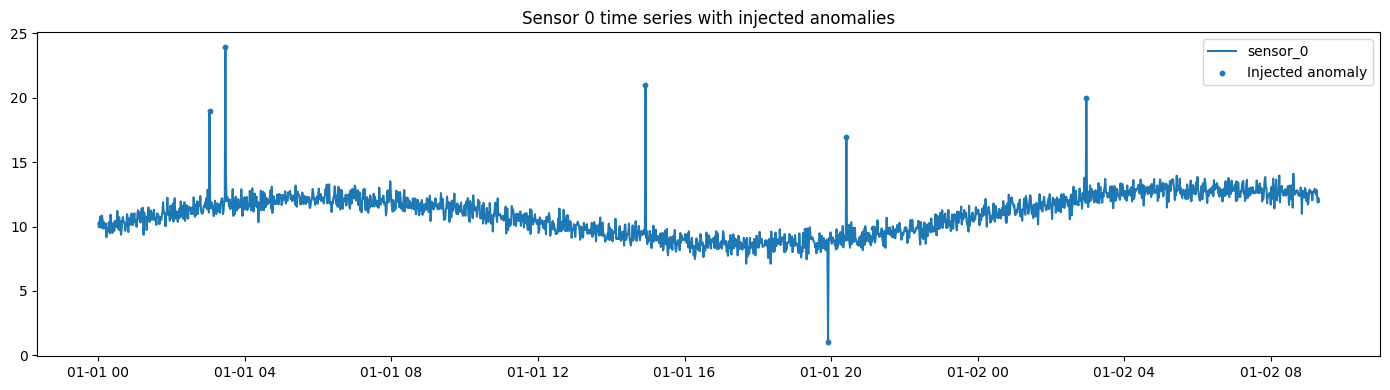

In [10]:
# %%
missing = data.isna().sum()
print('Missing values per column:\n', missing)

plt.figure(figsize=(14, 4))
plt.plot(data['timestamp'], data['sensor_0'], label='sensor_0')
plt.scatter(data.loc[data['is_anomaly'] == 1, 'timestamp'], data.loc[data['is_anomaly'] == 1, 'sensor_0'], s=10, label='Injected anomaly')
plt.title('Sensor 0 time series with injected anomalies')
plt.legend()
plt.tight_layout()
plt.savefig('figures/sensor0_time_series.png')
plt.show()


In [11]:
# %%
if data.isna().sum().sum() > 0:
    data.fillna(method='ffill', inplace=True)
    data.fillna(data.median(), inplace=True)
    logger.info('Filled missing values')

SENSOR_COLS = [c for c in data.columns if c.startswith('sensor_')]

def create_features(df, sensor_cols, rolling_windows=(5, 15, 60)):
    df = df.copy()
    for col in sensor_cols:
        df[f'{col}_diff1'] = df[col].diff().fillna(0)
        df[f'{col}_lag1'] = df[col].shift(1).fillna(df[col].iloc[0])
        for w in rolling_windows:
            df[f'{col}_roll_mean_{w}'] = df[col].rolling(window=w, min_periods=1).mean()
            df[f'{col}_roll_std_{w}'] = df[col].rolling(window=w, min_periods=1).std().fillna(0)
    return df

feat_df = create_features(data, SENSOR_COLS)
feat_df.index = pd.to_datetime(feat_df['timestamp'])
X = feat_df.drop(columns=['timestamp', 'is_anomaly'])
Y = feat_df['is_anomaly'].values

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
joblib.dump(scaler, 'models/scaler.pkl')
logger.info('Saved scaler')


IsolationForest -- Precision: 0.300, Recall: 0.600, F1: 0.400


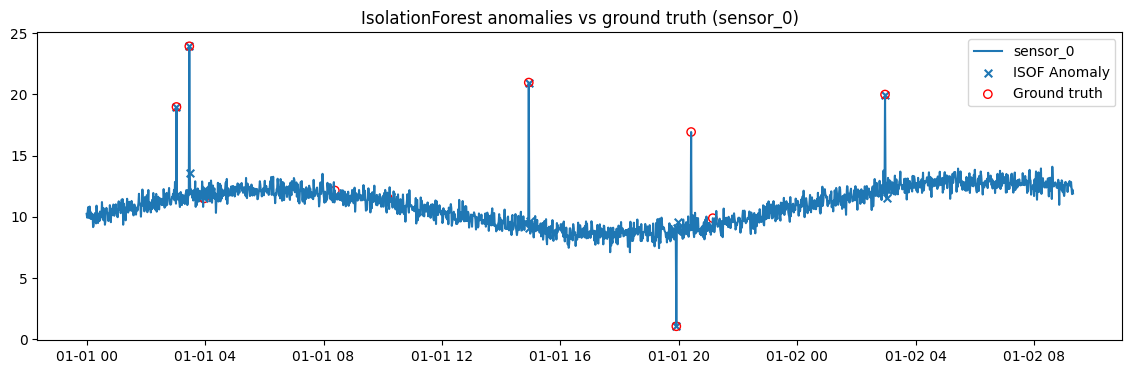

In [12]:
# %%
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=RANDOM_SEED)
iso.fit(X_scaled)
scores_iso = -iso.decision_function(X_scaled)
threshold = np.percentile(scores_iso, 99)
pred_iso = (scores_iso >= threshold).astype(int)

precision, recall, f1, _ = precision_recall_fscore_support(Y, pred_iso, average='binary', zero_division=0)
print(f'IsolationForest -- Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}')

plt.figure(figsize=(14, 4))
plt.plot(X_scaled.index, X['sensor_0'], label='sensor_0')
plt.scatter(X_scaled.index[pred_iso == 1], X['sensor_0'][pred_iso == 1], marker='x', s=30, label='ISOF Anomaly')
plt.scatter(X.index[Y == 1], X['sensor_0'][Y == 1], facecolors='none', edgecolors='r', label='Ground truth')
plt.legend()
plt.title('IsolationForest anomalies vs ground truth (sensor_0)')
plt.savefig('figures/isof_anomalies.png')
plt.show()
joblib.dump(iso, 'models/isolation_forest.pkl')
logger.info('Saved IsolationForest')


In [13]:
# %%
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_scaled)
lof_scores = -lof.decision_function(X_scaled)
lof_threshold = np.percentile(lof_scores, 99)
lof_anom = (lof_scores >= lof_threshold).astype(int)

precision_lof, recall_lof, f1_lof, _ = precision_recall_fscore_support(Y, lof_anom, average='binary', zero_division=0)
print(f'LOF (single-step) -- Precision: {precision_lof:.3f}, Recall: {recall_lof:.3f}, F1: {f1_lof:.3f}')
joblib.dump(lof, 'models/lof_model.pkl')
logger.info('Saved LOF model')


LOF (single-step) -- Precision: 0.450, Recall: 0.900, F1: 0.600


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


MLP Autoencoder -- Precision: 0.011, Recall: 1.000, F1: 0.022, AUC: 0.918


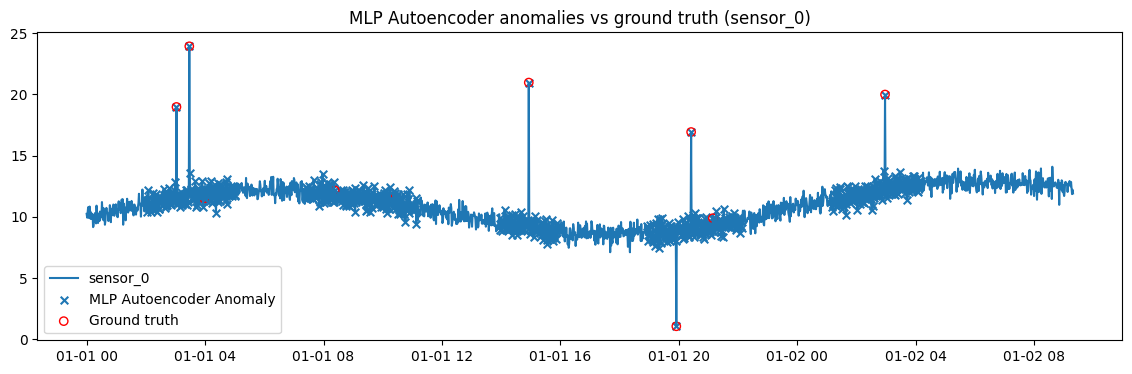

In [14]:
# %% [markdown]
# # Approach 2 - Neural Network Autoencoder (MLP)
SEQ_LEN = 60

def create_flattened_windows(df_scaled, seq_len=60):
    arr = df_scaled.values
    n, m = arr.shape
    if n < seq_len:
        return np.empty((0, seq_len * m))
    windows = np.array([arr[i:i+seq_len].ravel() for i in range(n - seq_len + 1)])
    return windows

windows = create_flattened_windows(X_scaled, SEQ_LEN)
num_windows = windows.shape[0]
seq_labels = np.array([int(Y[i:i+SEQ_LEN].sum() > 0) for i in range(num_windows)])

normal_idx = np.where(seq_labels == 0)[0]
max_train = min(2000, normal_idx.size)
train_sel = np.random.choice(normal_idx, size=max_train, replace=False)
X_train_ae = windows[train_sel]

mlp_ae = MLPRegressor(hidden_layer_sizes=(128,64,128), activation='relu', max_iter=300, random_state=RANDOM_SEED)
mlp_ae.fit(X_train_ae, X_train_ae)

X_pred_ae = mlp_ae.predict(windows)
recon_errors = np.mean((windows - X_pred_ae)**2, axis=1)
thresh_ae = recon_errors[normal_idx].mean() + 3 * recon_errors[normal_idx].std()

timestep_pred_ae = np.zeros(len(X_scaled), dtype=int)
counts = np.zeros(len(X_scaled), dtype=int)
accum = np.zeros(len(X_scaled), dtype=float)
for i, err in enumerate(recon_errors):
    start = i
    end = i + SEQ_LEN
    accum[start:end] += err
    counts[start:end] += 1
counts[counts == 0] = 1
timestep_errors = accum / counts
for i, val in enumerate(recon_errors > thresh_ae):
    if val:
        timestep_pred_ae[i:i+SEQ_LEN] = 1

Y_align = Y[:len(X_scaled)]
precision_ae, recall_ae, f1_ae, _ = precision_recall_fscore_support(Y_align, timestep_pred_ae, average='binary', zero_division=0)
try:
    auc_ae = roc_auc_score(Y_align, timestep_errors[:len(X_scaled)])
except Exception:
    auc_ae = float('nan')

print(f'MLP Autoencoder -- Precision: {precision_ae:.3f}, Recall: {recall_ae:.3f}, F1: {f1_ae:.3f}, AUC: {auc_ae:.3f}')

plt.figure(figsize=(14,4))
plt.plot(X.index[:len(X_scaled)], X['sensor_0'][:len(X_scaled)], label='sensor_0')
plt.scatter(X.index[:len(X_scaled)][timestep_pred_ae==1], X['sensor_0'].iloc[:len(X_scaled)][timestep_pred_ae==1], marker='x', s=30, label='MLP Autoencoder Anomaly')
plt.scatter(X.index[:len(X_scaled)][Y_align==1], X['sensor_0'].iloc[:len(X_scaled)][Y_align==1], facecolors='none', edgecolors='r', label='Ground truth')
plt.legend()
plt.title('MLP Autoencoder anomalies vs ground truth (sensor_0)')
plt.savefig('figures/mlp_autoencoder_anomalies.png')
plt.show()

joblib.dump(mlp_ae, 'models/mlp_autoencoder.pkl')
logger.info('Saved MLP Autoencoder model')


In [15]:
# %%
iso_pred_align = pred_iso[:len(Y_align)]
lof_pred_align = lof_anom[:len(Y_align)]

iso_precision, iso_recall, iso_f1, _ = precision_recall_fscore_support(Y_align, iso_pred_align, average='binary', zero_division=0)
lof_precision, lof_recall, lof_f1, _ = precision_recall_fscore_support(Y_align, lof_pred_align, average='binary', zero_division=0)

print('--- Model comparison ---')
print(f'IsolationForest  -- Precision: {iso_precision:.3f}, Recall: {iso_recall:.3f}, F1: {iso_f1:.3f}')
print(f'MLP Autoencoder  -- Precision: {precision_ae:.3f}, Recall: {recall_ae:.3f}, F1: {f1_ae:.3f}, AUC: {auc_ae:.3f}')
print(f'LOF (single-step)-- Precision: {lof_precision:.3f}, Recall: {lof_recall:.3f}, F1: {lof_f1:.3f}')

results = {
    'isolation_forest': {'precision': float(iso_precision), 'recall': float(iso_recall), 'f1': float(iso_f1)},
    'mlp_autoencoder': {'precision': float(precision_ae), 'recall': float(recall_ae), 'f1': float(f1_ae), 'auc': float(auc_ae) if not np.isnan(auc_ae) else None},
    'lof': {'precision': float(lof_precision), 'recall': float(lof_recall), 'f1': float(f1_lof)}
}

with open('models/metrics_summary.json', 'w') as fh:
    json.dump(results, fh, indent=2)
logger.info('Saved metrics summary')


--- Model comparison ---
IsolationForest  -- Precision: 0.300, Recall: 0.600, F1: 0.400
MLP Autoencoder  -- Precision: 0.011, Recall: 1.000, F1: 0.022, AUC: 0.918
LOF (single-step)-- Precision: 0.450, Recall: 0.900, F1: 0.600


In [16]:
# %%
README = '''# Time Series Anomaly Detection

## What's included
- Full pipeline with IsolationForest, LOF, and MLP Autoencoder
- models/ : saved model artifacts
- figures/ : saved visualizations
- models/metrics_summary.json : performance metrics

## How to run
1. Python 3.8+ environment, install dependencies: pip install -r requirements.txt
2. Run cells sequentially in Jupyter.
3. Replace synthetic data with load_real_data(path) for real dataset.

## Requirements
pandas, numpy, matplotlib, scikit-learn, joblib
'''

SUMMARY = '''# Summary: Anomaly Detection for IoT sensors

Problem: Detect anomalous sensor readings in multivariate time series.

Approach: IsolationForest (tree-based), MLP Autoencoder (sequence-level), LOF (density-based).

Feature engineering: Rolling statistics, first differences, lag features.
Scaling: StandardScaler applied.

Evaluation: Precision, recall, F1, AUC (for Autoencoder). Visual inspection of anomalies.

Limitations & future work:
- Test on real sensor data.
- LSTM/Transformer-based autoencoders for better temporal context.
- Adaptive thresholds and more advanced anomaly detection techniques.
'''

with open('README.md', 'w') as fh:
    fh.write(README)
with open('summary.md', 'w') as fh:
    fh.write(SUMMARY)
logger.info('README and summary written')
print('All done! Models, figures, README, and summary are ready.')


All done! Models, figures, README, and summary are ready.
